---

# LESSON 13: ADDING TEXT

---

>---
>You can **add text** at specific coordinates with the `text()` function
>
>- `ax.text(x-coordinate, y-coordinate, string`, additional text formatting`)`
>
>---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

In [2]:
df = pd.read_csv('../Data/ca_housing.csv', parse_dates=['period_begin'])

display(df.head(2), df.tail(2))
df.info()

,region_name,period_begin,period_end,total_homes_sold,inventory,active_listings,age_of_inventory,median_active_list_price,months_of_supply
0,Los Angeles,2018-08-20,2018-11-11,16015.0,20026.0,21675.0,51.9,694662.5,16.528985
1,Los Angeles,2017-12-25,2018-03-18,13596.0,13817.0,15251.0,51.3,664516.6,13.834214


,region_name,period_begin,period_end,total_homes_sold,inventory,active_listings,age_of_inventory,median_active_list_price,months_of_supply
832,San Francisco,2019-09-16,2019-12-08,1308.0,1084.0,1229.0,38.2,1481588.5,11.611986
833,Los Angeles,2021-06-28,2021-09-19,19525.0,14252.0,16098.0,35.5,888483.3,10.008760


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 834 entries, 0 to 833
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   region_name               834 non-null    object        
 1   period_begin              834 non-null    datetime64[ns]
 2   period_end                834 non-null    object        
 3   total_homes_sold          834 non-null    float64       
 4   inventory                 834 non-null    float64       
 5   active_listings           834 non-null    float64       
 6   age_of_inventory          834 non-null    float64       
 7   median_active_list_price  834 non-null    float64       
 8   months_of_supply          834 non-null    float64       
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 58.8+ KB


In [32]:
df_plot = (df
    .pivot_table(index='period_begin', columns='region_name', 
                 values='median_active_list_price', aggfunc='mean',
                 observed=True)
    .assign(ca_avg = lambda x: x.mean(axis=1)).round()
).resample('ME').mean().round()

display(df_plot.head(5), df_plot.tail(2))
df_plot.info()

region_name,Los Angeles,San Diego,San Francisco,ca_avg
period_begin,,,,
2017-01-31,617624.0,625689.0,1240735.0,828016.0
2017-02-28,633676.0,640141.0,1269452.0,847756.0
2017-03-31,643604.0,650277.0,1286000.0,859960.0
2017-04-30,649604.0,653915.0,1276834.0,860118.0
2017-05-31,650326.0,652674.0,1256150.0,853050.0


region_name,Los Angeles,San Diego,San Francisco,ca_avg
period_begin,,,,
2022-03-31,905437.0,900504.0,1290229.0,1032057.0
2022-04-30,906774.0,902425.0,1292479.0,1033893.0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 64 entries, 2017-01-31 to 2022-04-30
Freq: ME
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Los Angeles    64 non-null     float64
 1   San Diego      64 non-null     float64
 2   San Francisco  64 non-null     float64
 3   ca_avg         64 non-null     float64
dtypes: float64(4)
memory usage: 2.5 KB


<br><br>

---

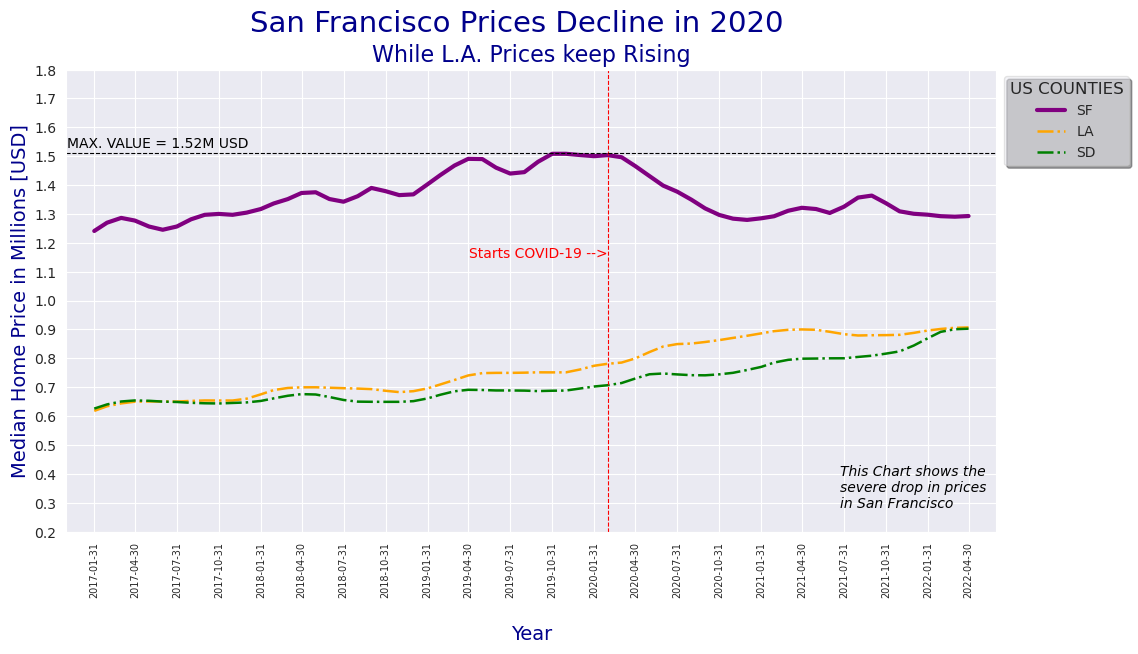

In [97]:
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot()
ax.plot(df_plot['San Francisco']/1e6, label='SF',
        linestyle='-', linewidth=3, color='purple')

ax.plot(df_plot['Los Angeles']/1e6, label='LA',
        linestyle='-.', linewidth=1.8, color='orange')

ax.plot(df_plot['San Diego']/1e6, label='SD',
        linestyle='-.', linewidth=1.8, color='green')

fig.suptitle('San Francisco Prices Decline in 2020', fontsize=21, color='darkblue')
ax.set_title('While L.A. Prices keep Rising', fontsize=16, color='darkblue')
ax.set_xlabel('Year', fontsize=14, color='darkblue', labelpad=20)
ax.set_ylabel('Median Home Price in Millions [USD]', fontsize=14, color='darkblue')

ax.legend(bbox_to_anchor=(1.15, 1),
          title='US COUNTIES',
          title_fontsize='large',
          fontsize='medium',
          shadow=True,
          framealpha=0.5,
          fancybox=True,
         )

ax.set_xlim(pd.Timestamp('2016-12-01'), pd.Timestamp('2022-06-30'))
ax.set_ylim(0.2, 1.8)

ax.set_xticks(df_plot.index[::3])
plt.xticks(rotation=90, fontsize=7)
ax.set_yticks(np.arange(0.2, 1.9, 0.1))

ax.axvline(pd.Timestamp('2020-03-01'), ls='--', linewidth=0.8, color='red')
ax.axhline(1.51, ls='--', linewidth=0.8, color='black')

ax.text(x=pd.Timestamp('2019-05-01'), y=1.15, s='Starts COVID-19 -->', color='red')
ax.text(x=pd.Timestamp('2016-12-03'), y=1.53, s='MAX. VALUE = 1.52M USD', color='black')

fig.text(x=0.77, y=0.15,
         s='This Chart shows the\nsevere drop in prices\nin San Francisco',
         fontstyle='italic', fontsize=10, color='black', )
    
plt.show()

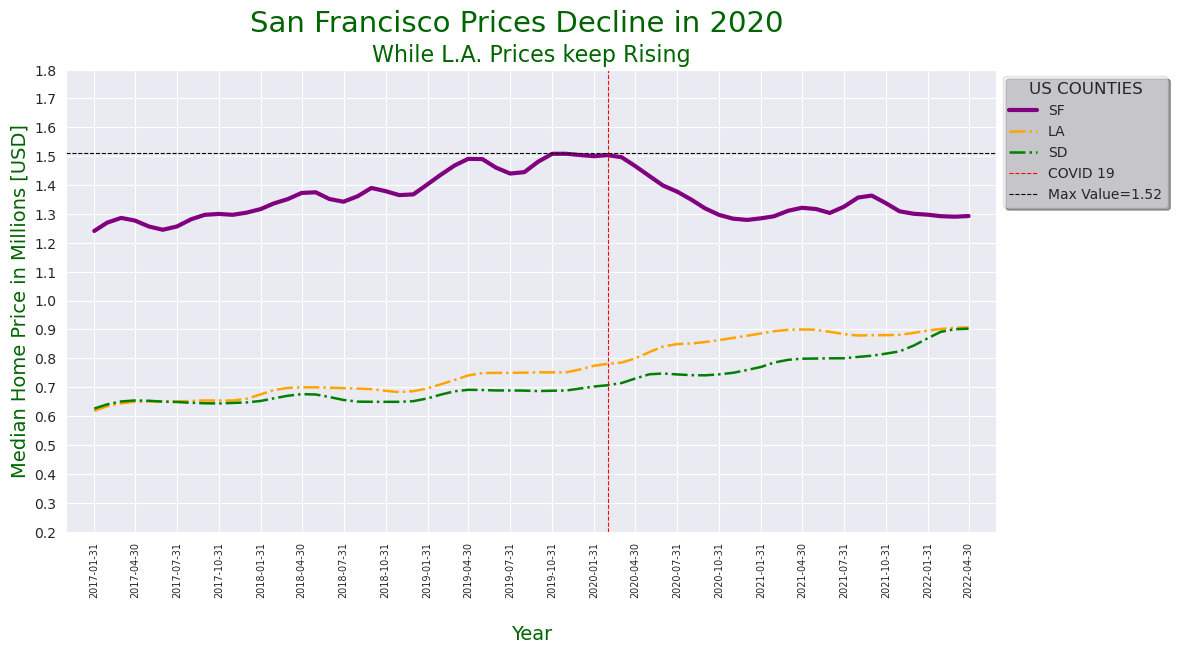

In [62]:
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot()
ax.plot(df_plot['San Francisco']/1e6, label='SF',
        linestyle='-', linewidth=3, color='purple')

ax.plot(df_plot['Los Angeles']/1e6, label='LA',
        linestyle='-.', linewidth=1.8, color='orange')

ax.plot(df_plot['San Diego']/1e6, label='SD',
        linestyle='-.', linewidth=1.8, color='green')

fig.suptitle('San Francisco Prices Decline in 2020', fontsize=21, color='darkgreen')
ax.set_title('While L.A. Prices keep Rising', fontsize=16, color='darkgreen')
ax.set_xlabel('Year', fontsize=14, color='darkgreen', labelpad=20)
ax.set_ylabel('Median Home Price in Millions [USD]', fontsize=14, color='darkgreen')



ax.set_xlim(pd.Timestamp('2016-12-01'), pd.Timestamp('2022-06-30'))
ax.set_ylim(0.2, 1.8)

ax.set_xticks(df_plot.index[::3])
plt.xticks(rotation=90, fontsize=7)
ax.set_yticks(np.arange(0.2, 1.9, 0.1))

ax.axvline(pd.Timestamp('2020-03-01'), ls='--', linewidth=0.8, color='red', label='COVID 19')
ax.axhline(1.51, ls='--', linewidth=0.8, color='black', label='Max Value=1.52')

ax.legend(bbox_to_anchor=(1, 1),
          title='US COUNTIES',
          title_fontsize='large',
          fontsize='medium',
          shadow=True,
          framealpha=0.5,
          fancybox=True,
         )
    
plt.show()